#Phần 1:

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import os

# Cài đặt chuẩn đồ họa học thuật
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['figure.figsize'] = (10, 6)

# Khai báo đường dẫn (Thay bằng đường dẫn Google Drive của bạn)
path = "/content/drive/MyDrive/datathon/"

# Load data
orders = pd.read_csv(os.path.join(path, "orders.csv"))
order_items = pd.read_csv(os.path.join(path, "order_items.csv"))
products = pd.read_csv(os.path.join(path, "products.csv"))
returns = pd.read_csv(os.path.join(path, "returns.csv"))
inventory = pd.read_csv(os.path.join(path, "inventory.csv"))

products = pd.read_csv(os.path.join(path, "products.csv"))
customers = pd.read_csv(os.path.join(path, "customers.csv"))
promotions = pd.read_csv(os.path.join(path, "promotions.csv"))
geography = pd.read_csv(os.path.join(path, "geography.csv"))

payments = pd.read_csv(os.path.join(path, "payments.csv"))
web_traffic = pd.read_csv(os.path.join(path, "web_traffic.csv"))

# Ép kiểu datetime
orders['order_date'] = pd.to_datetime(orders['order_date'])
sales['Date'] = pd.to_datetime(sales['Date'])

Câu 1: Trung vị số ngày giữa hai lần mua liên tiếp (inter-order gap)

Nhóm các đơn hàng theo khách hàng, sắp xếp theo ngày, tính số ngày chênh lệch giữa các lần mua, sau đó lọc những khách có > 1 đơn và tính trung vị (median).

In [44]:
# Sắp xếp đơn hàng theo user và ngày mua
orders_sorted = orders.sort_values(by=['customer_id', 'order_date'])

# Tạo cột ngày mua của đơn hàng liền trước đó
orders_sorted['prev_order_date'] = orders_sorted.groupby('customer_id')['order_date'].shift(1)

# Tính khoảng cách (gap) bằng ngày
orders_sorted['gap_days'] = (orders_sorted['order_date'] - orders_sorted['prev_order_date']).dt.days

# Tính số lượng đơn hàng của từng khách
order_counts = orders['customer_id'].value_counts()
multi_order_customers = order_counts[order_counts > 1].index

# Lọc khách hàng có >1 đơn và tính trung vị
q1_data = orders_sorted[orders_sorted['customer_id'].isin(multi_order_customers)]
ans_q1 = q1_data['gap_days'].median()
print("Câu 1 - Trung vị số ngày (Gap):", ans_q1)
# So sánh ans_q1 với các đáp án A(30), B(90), C(144), D(365) để chọn.


Câu 1 - Trung vị số ngày (Gap): 144.0


Câu 2: Phân khúc có tỷ suất lợi nhuận gộp trung bình cao nhất

Tỷ suất lợi nhuận = (price - cogs) / price. Tính cột này, group by theo segment và tính mean().

In [45]:
# Tạo cột margin
products['margin'] = (products['price'] - products['cogs']) / products['price']

# Nhóm theo phân khúc và tính trung bình
segment_margin = products.groupby('segment')['margin'].mean()

ans_q2 = segment_margin.idxmax() # Lấy tên phân khúc có giá trị cao nhất
print("Câu 2 - Phân khúc lợi nhuận cao nhất:", ans_q2)
print("Chi tiết các mức lợi nhuận:\n", segment_margin)


Câu 2 - Phân khúc lợi nhuận cao nhất: Standard
Chi tiết các mức lợi nhuận:
 segment
Activewear     0.265600
All-weather    0.284176
Balanced       0.258038
Everyday       0.236343
Performance    0.263650
Premium        0.285377
Standard       0.313442
Trendy         0.240758
Name: margin, dtype: float64


Câu 3: Lý do trả hàng nhiều nhất của Streetwear
 Nối (Join) bảng returns và products qua product_id. Lọc danh mục 'Streetwear' và đếm lý do.

In [46]:
# Nối bảng
returns_products = pd.merge(returns, products, on='product_id', how='left')

# Lọc Streetwear
streetwear_returns = returns_products[returns_products['category'] == 'Streetwear']

# Đếm tần suất các lý do
reason_counts = streetwear_returns['return_reason'].value_counts()
ans_q3 = reason_counts.idxmax()

print("Câu 3 - Lý do trả hàng Streetwear phổ biến nhất:", ans_q3)

Câu 3 - Lý do trả hàng Streetwear phổ biến nhất: wrong_size


Câu 4: Nguồn truy cập có bounce rate thấp nhất

Group by traffic_source trong bảng web_traffic và tính trung bình của bounce_rate.

In [47]:
bounce_rate_by_source = web_traffic.groupby('traffic_source')['bounce_rate'].mean()
ans_q4 = bounce_rate_by_source.idxmin()

print("Câu 4 - Nguồn có Bounce Rate thấp nhất:", ans_q4)

Câu 4 - Nguồn có Bounce Rate thấp nhất: email_campaign


Câu 5: Tỷ lệ phần trăm có áp dụng khuyến mãi

Đếm số dòng mà cột promo_id không bị rỗng (not null) chia cho tổng số dòng trong order_items.

In [48]:
total_items = len(order_items)
items_with_promo = order_items['promo_id'].notnull().sum()

ans_q5 = (items_with_promo / total_items) * 100
print(f"Câu 5 - Tỷ lệ áp dụng khuyến mãi: {ans_q5:.2f}%")

Câu 5 - Tỷ lệ áp dụng khuyến mãi: 38.66%


Câu 6: Nhóm tuổi có số đơn trung bình cao nhất

Số đơn trung bình = (Tổng số đơn của nhóm tuổi) / (Số lượng khách hàng thuộc nhóm tuổi đó).

In [49]:
# Lọc khách hàng có age_group (khác null)
valid_customers = customers[customers['age_group'].notnull()]

# Tính số lượng khách hàng từng nhóm tuổi
cust_count_by_age = valid_customers['age_group'].value_counts()

# Nối order với valid_customers để biết đơn hàng thuộc nhóm tuổi nào
orders_with_age = pd.merge(orders, valid_customers[['customer_id', 'age_group']], on='customer_id', how='inner')

# Đếm tổng số đơn hàng của từng nhóm tuổi
order_count_by_age = orders_with_age.groupby('age_group')['order_id'].count()

# Tính trung bình (Lưu ý: chia 2 Series cùng index)
avg_orders_by_age = order_count_by_age / cust_count_by_age

ans_q6 = avg_orders_by_age.idxmax()
print("Câu 6 - Nhóm tuổi mua nhiều đơn trung bình nhất:", ans_q6)


Câu 6 - Nhóm tuổi mua nhiều đơn trung bình nhất: 55+


Câu 7: Vùng (region) tạo doanh thu cao nhất

 tính tổng doanh thu thông qua order_items -> orders -> geography. (Doanh thu = unit_price * quantity - discount_amount).

In [50]:
# Tính doanh thu của từng dòng item
order_items['revenue'] = (order_items['unit_price'] * order_items['quantity']) - order_items['discount_amount'].fillna(0)

# Tổng doanh thu theo order_id
revenue_per_order = order_items.groupby('order_id')['revenue'].sum().reset_index()

# Nối orders với geography để lấy region
orders_geo = pd.merge(orders, geography, on='zip', how='left')

# Nối tiếp với doanh thu
orders_geo_rev = pd.merge(orders_geo, revenue_per_order, on='order_id', how='left')

# Nhóm theo vùng và tính tổng
revenue_by_region = orders_geo_rev.groupby('region')['revenue'].sum()

ans_q7 = revenue_by_region.idxmax()
print("Câu 7 - Vùng có doanh thu cao nhất:", ans_q7)

Câu 7 - Vùng có doanh thu cao nhất: East


Câu 8: Phương thức thanh toán khi bị Huỷ (cancelled)

Lọc orders có status = 'cancelled', đếm payment_method.

In [51]:
cancelled_orders = orders[orders['order_status'] == 'cancelled']
cancelled_payments = cancelled_orders['payment_method'].value_counts()

ans_q8 = cancelled_payments.idxmax()
print("Câu 8 - Phương thức thanh toán khi bị huỷ nhiều nhất:", ans_q8)

Câu 8 - Phương thức thanh toán khi bị huỷ nhiều nhất: credit_card


Câu 9: Kích thước có tỷ lệ trả hàng cao nhất

Tỷ lệ = (Số bản ghi trong returns của size đó) / (Số bản ghi trong order_items của size đó).

In [52]:
# Nối lấy size cho order_items
items_with_size = pd.merge(order_items, products[['product_id', 'size']], on='product_id', how='left')
# Nối lấy size cho returns
returns_with_size = pd.merge(returns, products[['product_id', 'size']], on='product_id', how='left')

# Đếm số lượng theo size
size_ordered = items_with_size['size'].value_counts()
size_returned = returns_with_size['size'].value_counts()

# Tính tỷ lệ (Chỉ quan tâm S, M, L, XL)
return_rates = (size_returned / size_ordered)[['S', 'M', 'L', 'XL']]

ans_q9 = return_rates.idxmax()
print("Câu 9 - Kích thước có tỷ lệ trả hàng cao nhất:", ans_q9)
print("Chi tiết tỷ lệ trả hàng:\n", return_rates)

Câu 9 - Kích thước có tỷ lệ trả hàng cao nhất: S
Chi tiết tỷ lệ trả hàng:
 size
S     0.056515
M     0.055660
L     0.056250
XL    0.055200
Name: count, dtype: float64


Câu 10: Kỳ trả góp có giá trị trung bình cao nhất

Dùng bảng payments, group by installments và tính mean cho payment_value.

In [53]:
avg_payment_by_installment = payments.groupby('installments')['payment_value'].mean()
ans_q10 = avg_payment_by_installment.idxmax()

print("Câu 10 - Kỳ trả góp có giá trị thanh toán trung bình cao nhất:", ans_q10)


Câu 10 - Kỳ trả góp có giá trị thanh toán trung bình cao nhất: 6


PHẦN 2: TRỰC QUAN HÓA DỮ LIỆU



## **I. DESCRIPTIVE (DOANH NGHIỆP ĐANG VẬN HÀNH NHƯ THẾ NÀO?)**

### 1. Xu hướng Doanh thu và Đơn hàng theo thời gian

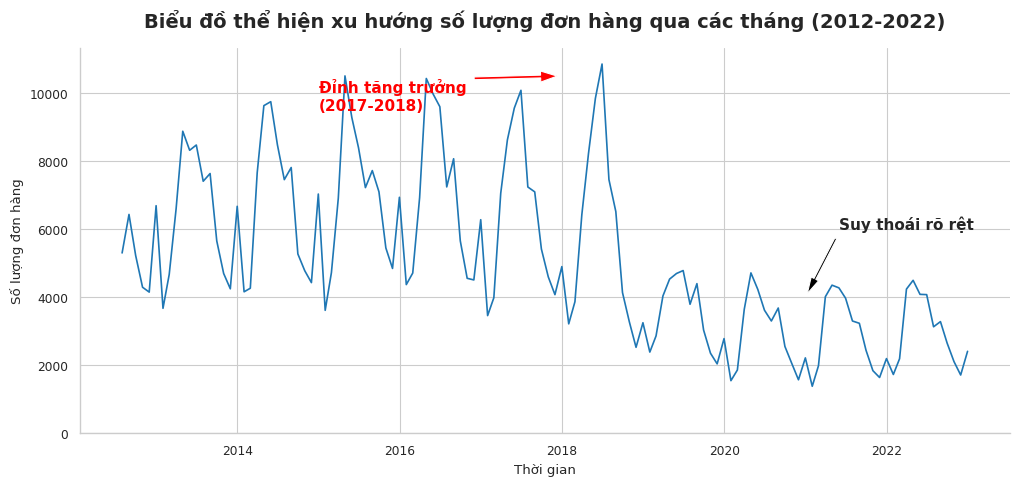

In [54]:
orders_by_month = orders.set_index('order_date').resample('M').size().reset_index(name='count')

plt.figure(figsize=(12, 5))
ax = sns.lineplot(data=orders_by_month, x='order_date', y='count', color='#1f77b4')

# Thêm tiêu đề mới
plt.title("Biểu đồ thể hiện xu hướng số lượng đơn hàng qua các tháng (2012-2022)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Thời gian")
plt.ylabel("Số lượng đơn hàng")

ax.set_ylim(bottom=0)
# ĐÁNH DẤU (ANNOTATION)
plt.annotate('Đỉnh tăng trưởng\n(2017-2018)',
             xy=(pd.to_datetime('2018-01-01'), 10500),
             xytext=(pd.to_datetime('2015-01-01'), 9500),
             arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
             color='red', fontweight='bold', fontsize=11)

plt.annotate('Suy thoái rõ rệt',
             xy=(pd.to_datetime('2021-01-01'), 4000),
             xytext=(pd.to_datetime('2021-06-01'), 6000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
             fontweight='bold', fontsize=11)

sns.despine()
plt.show()


Doanh nghiệp đạt đỉnh tăng trưởng vào 2017-2018, sau đó giảm dần và đi ngang. Giá trị trung bình đơn (AOV) cực kỳ thấp (~24.238 VNĐ). Tăng trưởng hiện tại phụ thuộc hoàn toàn vào số lượng đơn, không phải giá trị đơn.

### 2. Cấu trúc Doanh thu (Đến từ đâu?)

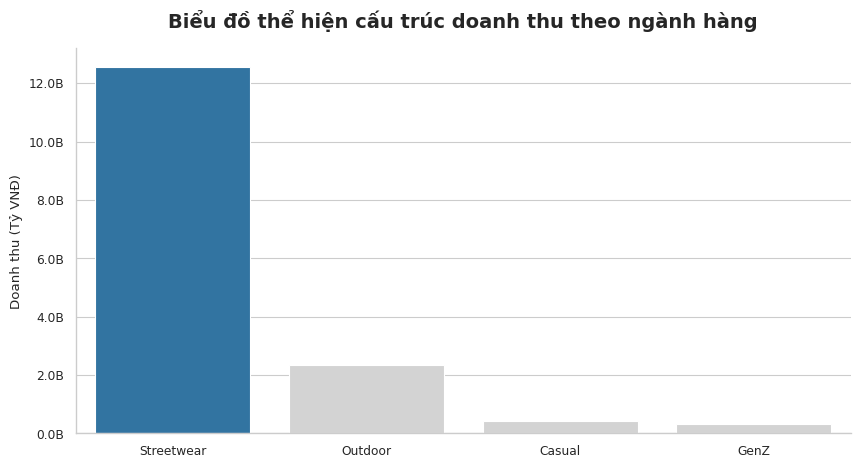

In [55]:
df_rev = order_items.merge(products, on='product_id')
df_rev['item_revenue'] = df_rev['quantity'] * df_rev['unit_price'] - df_rev['discount_amount'].fillna(0)
cat_rev = df_rev.groupby('category')['item_revenue'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
colors = ['#1f77b4' if cat == 'Streetwear' else '#d3d3d3' for cat in cat_rev['category']]
ax = sns.barplot(data=cat_rev, x='category', y='item_revenue', palette=colors)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-9:.1f}B'))

# Tiêu đề mới
plt.title("Biểu đồ thể hiện cấu trúc doanh thu theo ngành hàng", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Doanh thu (Tỷ VNĐ)")
plt.xlabel("")

sns.despine()
plt.show()


In [56]:
import plotly.graph_objects as go
import pandas as pd

# 1. Kết hợp dữ liệu (df_full)
df_full = order_items.merge(products[['product_id', 'category']], on='product_id') \
                     .merge(orders[['order_id', 'zip']], on='order_id') \
                     .merge(geography[['zip', 'region']], on='zip')

# Tính Doanh thu thuần
df_full['item_revenue'] = (df_full['quantity'] * df_full['unit_price']) - df_full['discount_amount']
sankey_data = df_full.groupby(['region', 'category'])['item_revenue'].sum().reset_index()

# 2. Định nghĩa Nodes và Bảng màu
regions = list(sankey_data['region'].unique())
categories = list(sankey_data['category'].unique())
all_nodes = regions + categories

custom_colors = [
    '#32BE78', # Xanh lá
    '#3CA0E6', # Xanh dương
    '#F4A261', # Cam pastel
    '#B8A1E3', # Tím pastel
    '#45B7D1', # Xanh lơ
    '#F6D28B', # Vàng pastel
    '#FF9EB5', # Hồng pastel
    '#9B59B6'  # Tím đậm
]
node_colors = [custom_colors[i % len(custom_colors)] for i in range(len(all_nodes))]
color_map = dict(zip(all_nodes, node_colors))

# 3. Tạo nhãn hiển thị doanh thu và tính toán cho Legend
node_labels = []
node_revenues = {}
for node in all_nodes:
    rev = df_full[df_full['region'] == node]['item_revenue'].sum() + \
          df_full[df_full['category'] == node]['item_revenue'].sum()
    node_revenues[node] = rev
    node_labels.append(f"<b>{node.upper()}</b><br>${rev:,.0f}")

# 4. Ánh xạ Link (Dòng chảy)
node_map = {name: i for i, name in enumerate(all_nodes)}
sources = [node_map[r] for r in sankey_data['region']]
targets = [node_map[c] for c in sankey_data['category']]
values = sankey_data['item_revenue']

def hex_to_rgba(hex_code, opacity=0.25):
    hex_code = hex_code.lstrip('#')
    rgb = tuple(int(hex_code[i:i+2], 16) for i in (0, 2, 4))
    return f'rgba({rgb[0]}, {rgb[1]}, {rgb[2]}, {opacity})'

link_colors = [hex_to_rgba(color_map[r], 0.25) for r in sankey_data['region']]

# 5. Vẽ biểu đồ
fig = go.Figure()

fig.add_trace(go.Sankey(
    textfont=dict(color="white", size=10),
    node = dict(
        pad = 30, thickness = 60,
        line = dict(color = "white", width = 1),
        label = node_labels,
        color = node_colors
    ),
    link = dict(
        source = sources, target = targets,
        value = values, color = link_colors
    ),
    # Nới rộng domain x để biểu đồ dài hơn theo chiều ngang
    domain=dict(x=[0, 0.85])
))

# 6. Thêm bảng chú thích (Legend)
for name in all_nodes:
    fig.add_trace(go.Scatter(
        x=[None], y=[None],
        mode='markers',
        marker=dict(size=12, color=color_map[name], symbol='square'),
        name=f"{name.upper()}: ${node_revenues[name]:,.0f}",
        showlegend=True
    ))

# 7. Tinh chỉnh Layout: NỀN TRẮNG, CĂN GIỮA TITLE, KÉO DÀI NGANG
fig.update_layout(
    title={
        'text': "<b>BIỂU ĐỒ DÒNG CHẢY DOANH THU THEO KHU VỰC & DANH MỤC SẢN PHẨM</b>",
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=22)
    },
    width=1200, # Tăng chiều ngang khung hình
    height=700,
    font_family="Arial",
    paper_bgcolor='white',
    plot_bgcolor='white',
    legend=dict(
        title="<b>DANH MỤC & DOANH THU</b>",
        x=0.87, # Đẩy legend sang phải để không đè lên biểu đồ đã kéo dài
        y=0.5,
        xanchor="left",
        font=dict(size=10, color="black"),
        bordercolor="lightgray",
        borderwidth=1
    ),
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    margin=dict(t=120, b=50, l=50, r=50) # Tăng margin top cho tiêu đề thoáng
)

fig.show()

 Rủi ro tập trung (Concentration Risk) cực cao. Doanh thu phụ thuộc gần như hoàn toàn vào "Streetwear". Nếu xu hướng này bão hòa, toàn bộ hệ thống sẽ sụp đổ.

## **II. DIAGNOSTIC (TẠI SAO LẠI XẢY RA?)**

Từ Descriptive, chúng ta rút ra 2 vấn đề lớn nhất cần chẩn đoán:

1. Vì sao đơn hàng giảm sau 2018?

2. Vì sao AOV lại thấp kỷ lục (~24k)?

**VẤN ĐỀ 1: VÌ SAO ĐƠN HÀNG GIẢM SAU 2018?**

Giả thuyết: Mất khách hàng (Retention thấp) hay Khách mua ít đơn hơn (Engagement giảm)?

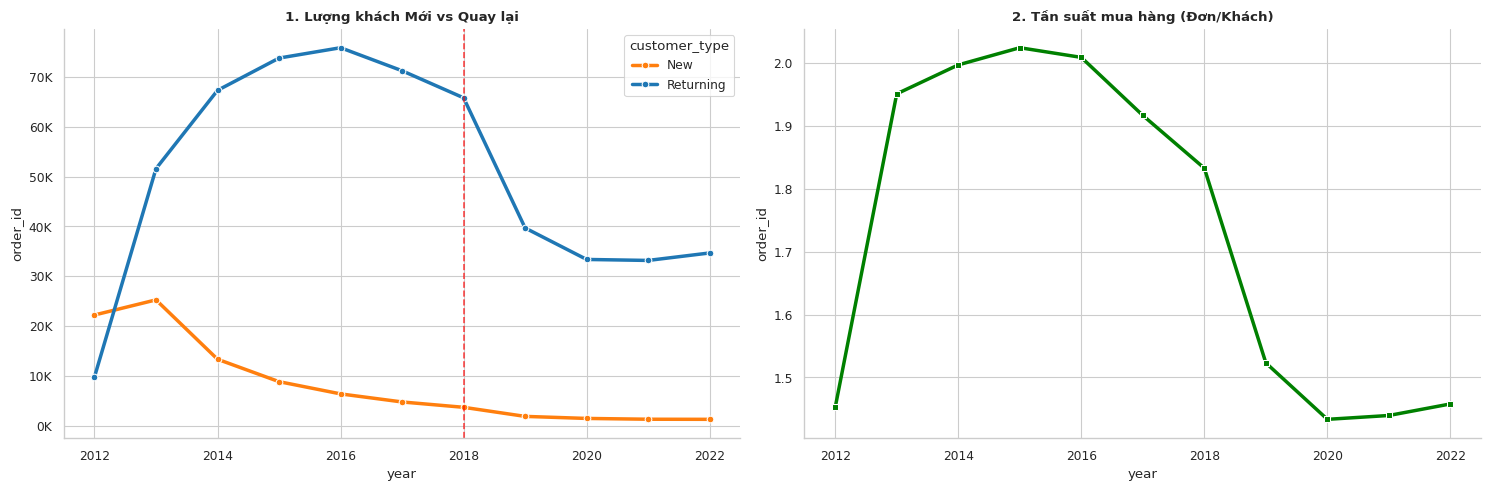

In [57]:
# Kiểm tra H1: Khách mới vs Khách quay lại
first_purchase = orders.groupby('customer_id')['order_date'].min().reset_index()
first_purchase.columns = ['customer_id', 'first_order_date']
orders_merge = orders.merge(first_purchase, on='customer_id')
orders_merge['customer_type'] = np.where(orders_merge['order_date'] == orders_merge['first_order_date'], 'New', 'Returning')
orders_merge['year'] = orders_merge['order_date'].dt.year
customer_trend = orders_merge.groupby(['year', 'customer_type'])['order_id'].count().reset_index()

# Kiểm tra H2: Số đơn trung bình / Khách hàng
orders_per_customer = orders_merge.groupby(['year', 'customer_id'])['order_id'].count().reset_index()
avg_orders = orders_per_customer.groupby('year')['order_id'].mean().reset_index()

# Vẽ 2 biểu đồ cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ 1
sns.lineplot(ax=axes[0], data=customer_trend, x='year', y='order_id', hue='customer_type', marker='o', linewidth=2.5, palette=['#ff7f0e', '#1f77b4'])
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-3:.0f}K'))
axes[0].set_title("1. Lượng khách Mới vs Quay lại", fontweight='bold')
axes[0].axvline(x=2018, color='red', linestyle='--', alpha=0.7)

# Biểu đồ 2
sns.lineplot(ax=axes[1], data=avg_orders, x='year', y='order_id', marker='s', color='green', linewidth=2.5)
axes[1].set_title("2. Tần suất mua hàng (Đơn/Khách)", fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()


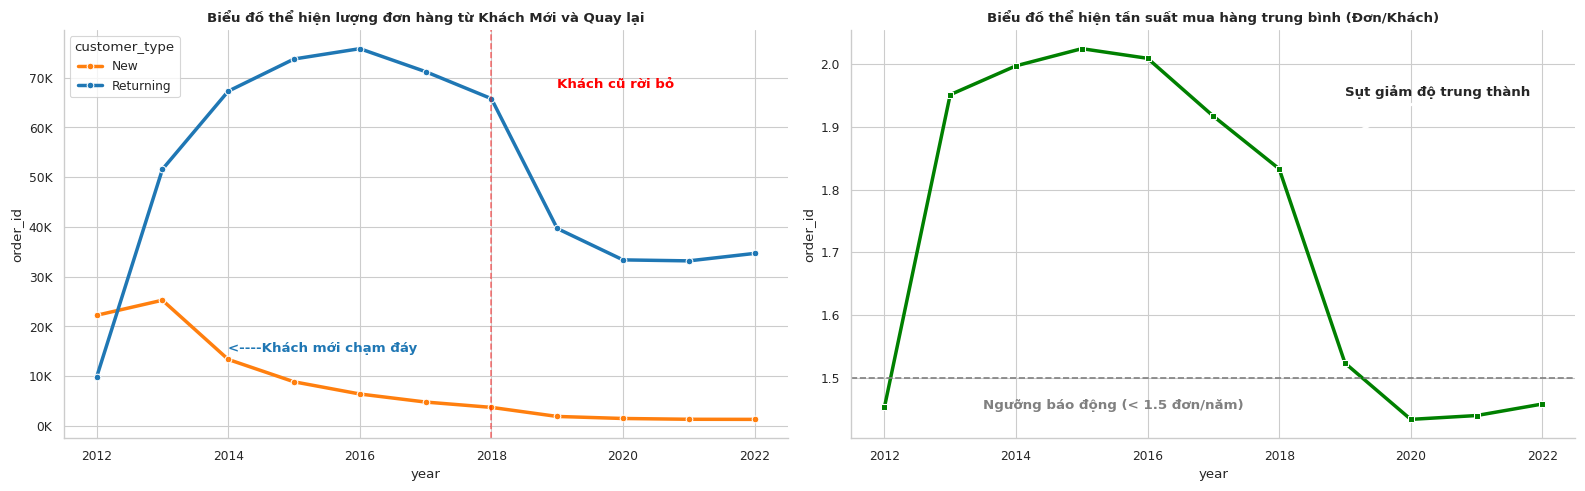

In [58]:
# Tính toán
first_purchase = orders.groupby('customer_id')['order_date'].min().reset_index()
first_purchase.columns = ['customer_id', 'first_order_date']
orders_merge = orders.merge(first_purchase, on='customer_id')
orders_merge['customer_type'] = np.where(orders_merge['order_date'] == orders_merge['first_order_date'], 'New', 'Returning')
orders_merge['year'] = orders_merge['order_date'].dt.year
customer_trend = orders_merge.groupby(['year', 'customer_type'])['order_id'].count().reset_index()

orders_per_customer = orders_merge.groupby(['year', 'customer_id'])['order_id'].count().reset_index()
avg_orders = orders_per_customer.groupby('year')['order_id'].mean().reset_index()

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Đồ thị trái
sns.lineplot(ax=axes[0], data=customer_trend, x='year', y='order_id', hue='customer_type', marker='o', linewidth=2.5, palette=['#ff7f0e', '#1f77b4'])
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-3:.0f}K'))
axes[0].set_title("Biểu đồ thể hiện lượng đơn hàng từ Khách Mới và Quay lại", fontweight='bold')
axes[0].axvline(x=2018, color='red', linestyle='--', alpha=0.5)

# Đánh dấu đồ thị trái
axes[0].annotate('Khách cũ rời bỏ', xy=(2018, 65000), xytext=(2019, 68000),
                 arrowprops=dict(facecolor='red', arrowstyle='->', lw=2), color='red', fontweight='bold')
axes[0].text(2014, 15000, '<----Khách mới chạm đáy', color='#1f77b4', fontweight='bold')

# Đồ thị phải
sns.lineplot(ax=axes[1], data=avg_orders, x='year', y='order_id', marker='s', color='green', linewidth=2.5)
axes[1].set_title("Biểu đồ thể hiện tần suất mua hàng trung bình (Đơn/Khách)", fontweight='bold')

# Đánh dấu đồ thị phải
axes[1].axhline(y=1.5, color='gray', linestyle='--')
axes[1].text(2013.5, 1.45, 'Ngưỡng báo động (< 1.5 đơn/năm)', color='gray', fontweight='bold')
axes[1].annotate('Sụt giảm độ trung thành', xy=(2018, 1.83), xytext=(2019, 1.95),
                 arrowprops=dict(facecolor='black', arrowstyle='->', lw=2), fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

**Sự sụt giảm "Kép"**
Doanh nghiệp không chỉ mất khả năng thu hút khách mới (Acquisition hỏng từ 2013), mà ngay cả độ trung thành của khách cũ cũng sụp đổ (Từ 2.03 đơn/khách giảm còn 1.45 đơn/khách). Sự suy giảm sau 2018 là hệ quả tất yếu khi "bầu sữa" khách hàng cũ cạn kiệt.

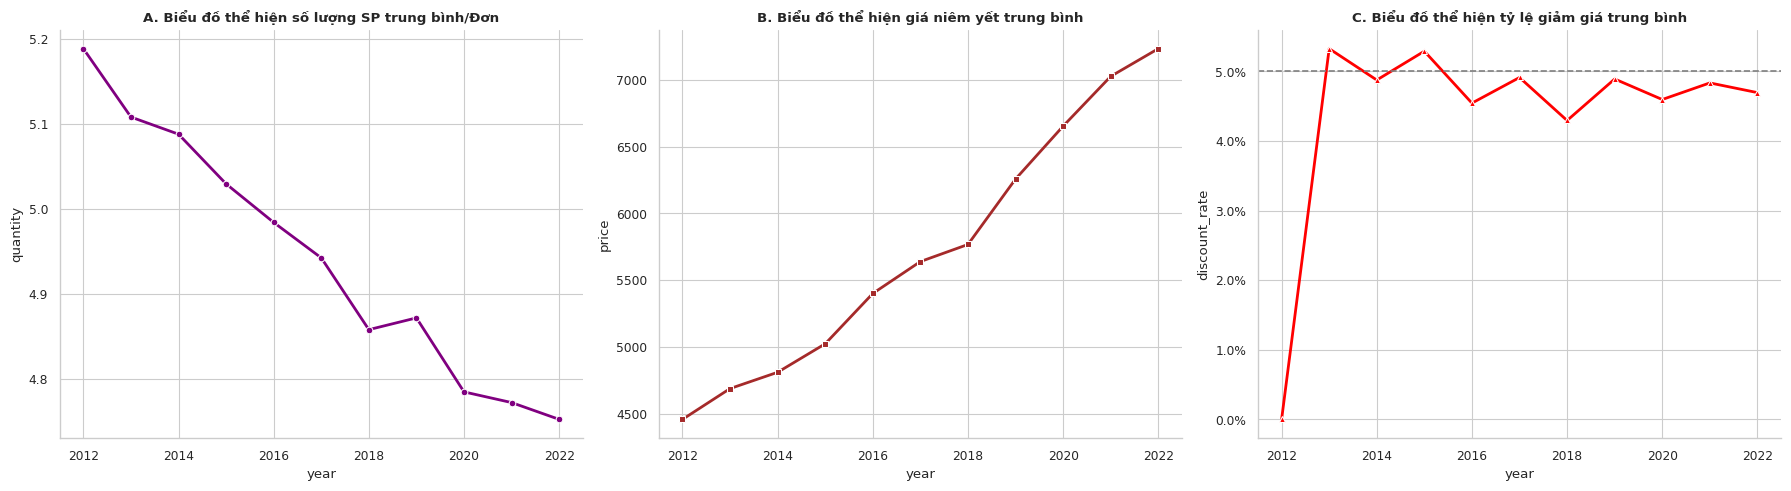

In [59]:
# Tính toán
df_aov = order_items.merge(products[['product_id', 'price']], on='product_id', how='left')
df_aov = df_aov.merge(orders[['order_id', 'order_date']], on='order_id', how='left')
df_aov['year'] = df_aov['order_date'].dt.year

avg_items = df_aov.groupby(['order_id', 'year'])['quantity'].sum().reset_index().groupby('year')['quantity'].mean().reset_index()
avg_price = df_aov[df_aov['quantity']>0].groupby('year')['price'].mean().reset_index()
df_aov['discount_rate'] = (df_aov['discount_amount'] / (df_aov['quantity'] * df_aov['price'])).fillna(0)
avg_discount = df_aov.groupby('year')['discount_rate'].mean().reset_index()

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A. Số SP/Đơn
sns.lineplot(ax=axes[0], data=avg_items, x='year', y='quantity', marker='o', color='purple', linewidth=2)
axes[0].set_title("A. Biểu đồ thể hiện số lượng SP trung bình/Đơn", fontweight='bold')
#axes[0].annotate('Giỏ hàng mỏng dần\n(Khách mua ít đi)', xy=(2020, 4.8), xytext=(2015, 4.85),
                 #arrowprops=dict(facecolor='purple', arrowstyle='->', lw=2), color='purple', fontweight='bold')

# B. Giá niêm yết
sns.lineplot(ax=axes[1], data=avg_price, x='year', y='price', marker='s', color='brown', linewidth=2)
axes[1].set_title("B. Biểu đồ thể hiện giá niêm yết trung bình", fontweight='bold')
#axes[1].annotate('Giá bán tăng liên tục', xy=(2020, 6000), xytext=(2013, 5500),
                 #arrowprops=dict(facecolor='brown', arrowstyle='->', lw=2), color='brown', fontweight='bold')

# C. Tỷ lệ giảm giá
sns.lineplot(ax=axes[2], data=avg_discount, x='year', y='discount_rate', marker='^', color='red', linewidth=2)
axes[2].yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
axes[2].set_title("C. Biểu đồ thể hiện tỷ lệ giảm giá trung bình", fontweight='bold')
axes[2].axhline(y=0.05, color='gray', linestyle='--')
#axes[2].text(2013, 0.051, 'Bẫy khuyến mãi đi ngang (~5%)', color='red', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

Cái bẫy Khuyến mãi
Biểu đồ trên tiết lộ một mâu thuẫn (Tension) cấu trúc chí mạng:

Giá niêm yết (Biểu đồ B) tăng liên tục từ 4,000 lên 6,500 VNĐ.

Nhưng mức giảm giá (Biểu đồ C) lại giữ nguyên ở mức lửng lơ ~5% suốt 10 năm.

Hệ quả (Biểu đồ A): Khách hàng phản ứng phòng thủ. Vì giá tăng nhưng mã giảm giá quá bèo bọt (không đủ hấp dẫn để mua thêm), khách hàng từ chối mua kèm (cross-sell). Họ thu hẹp giỏ hàng, chỉ mua 1 món rẻ nhất cốt để xài cái voucher 5%. Đây là nguyên nhân gốc rễ dìm AOV xuống đáy. Khuyến mãi lúc này không mang lại tăng trưởng mà chỉ bào mòn 5% doanh thu thuần.

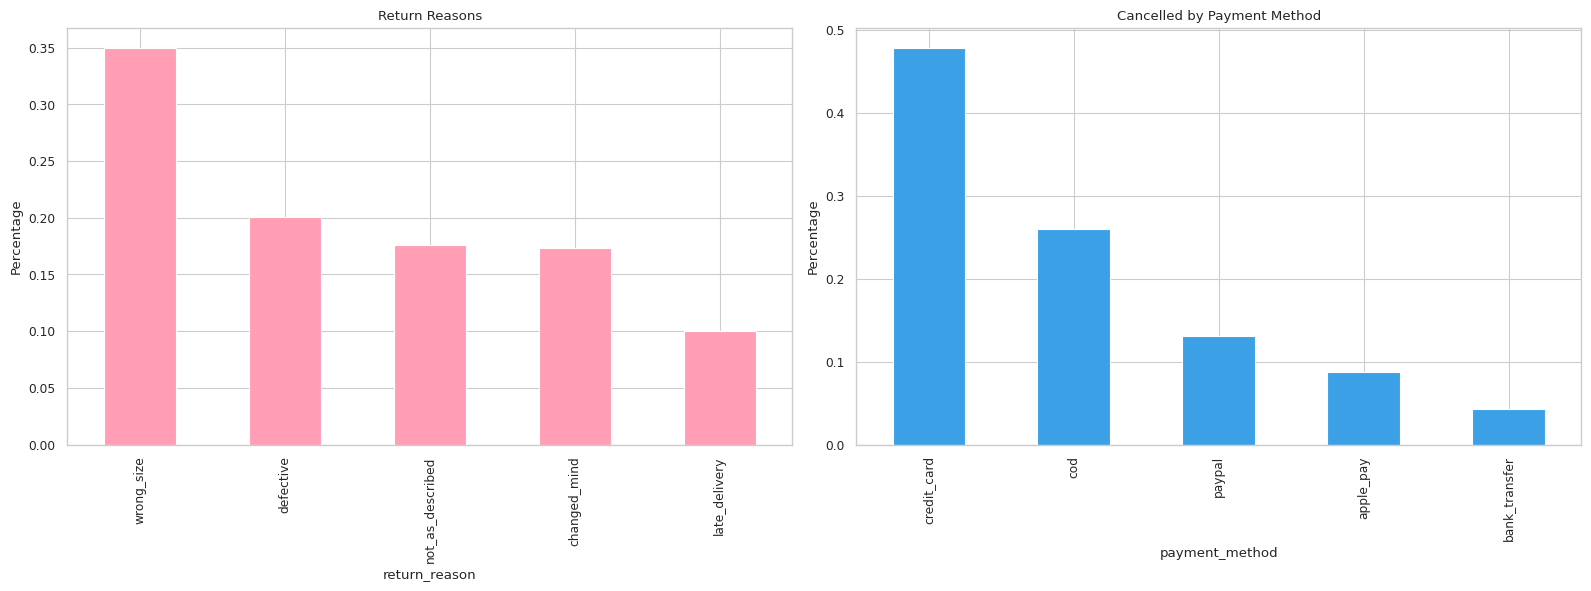

In [60]:
import matplotlib.pyplot as plt

# 1. Chuẩn bị dữ liệu (Lấy từ các bảng đã merge hoặc trực tiếp)
# Dữ liệu Trả hàng
return_reason = returns['return_reason'].value_counts(normalize=True)

# Dữ liệu Hủy đơn
cancelled_orders = orders[orders['order_status'] == 'cancelled']
cancel_by_payment = cancelled_orders['payment_method'].value_counts(normalize=True)

# 2. Xóa các hình vẽ cũ đang treo trong bộ nhớ
plt.close('all')

# 3. Tạo khung mới: 1 hàng, 2 cột
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Vẽ biểu đồ 1
return_reason.plot(kind='bar', ax=ax1, color='#FF9EB5')
ax1.set_title('Return Reasons')
ax1.set_ylabel('Percentage')

# Vẽ biểu đồ 2
cancel_by_payment.plot(kind='bar', ax=ax2, color='#3CA0E6')
ax2.set_title('Cancelled by Payment Method')
ax2.set_ylabel('Percentage')

# Căn chỉnh và hiển thị
plt.tight_layout()
plt.show()

## **III.PREDICTIVE**

Đây là phần ĐÓNG VAI TRÒ BẮC CẦU. Chúng ta sẽ phân tích Tính mùa vụ (Seasonality) và Ngoại suy xu hướng (Trend Extrapolation).

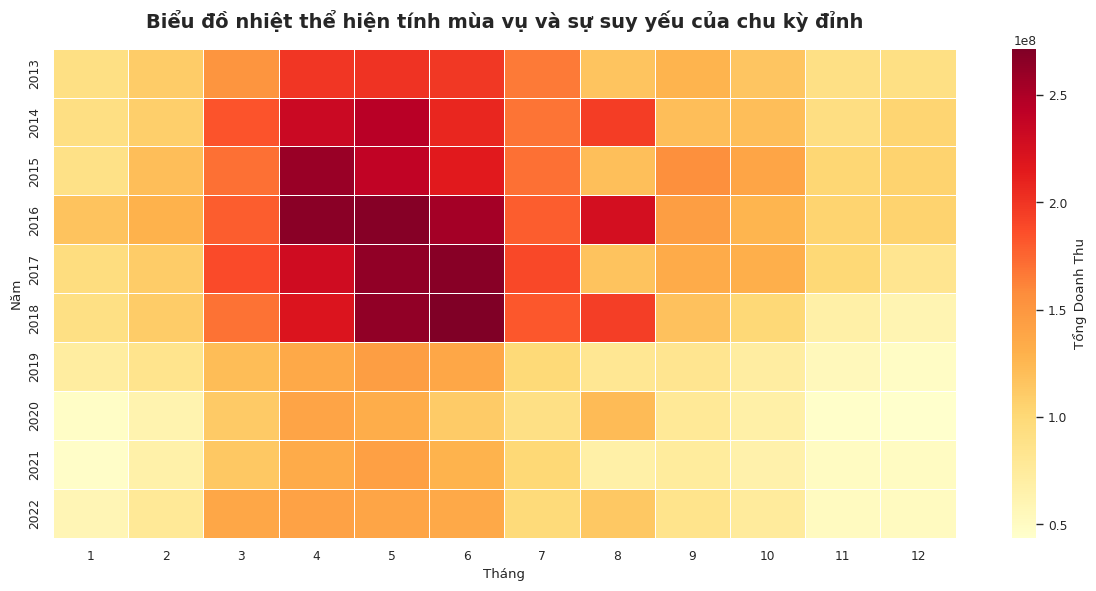

In [61]:
# Xử lý dữ liệu
sales['Year'] = sales['Date'].dt.year
sales['Month'] = sales['Date'].dt.month
sales_full_years = sales[sales['Year'] > 2012]
seasonality = sales_full_years.pivot_table(index='Year', columns='Month', values='Revenue', aggfunc='sum')

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
ax = sns.heatmap(seasonality, cmap='YlOrRd', linewidths=.5, cbar_kws={'label': 'Tổng Doanh Thu'})

# Tiêu đề
plt.title("Biểu đồ nhiệt thể hiện tính mùa vụ và sự suy yếu của chu kỳ đỉnh", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Tháng")
plt.ylabel("Năm")

plt.tight_layout()
plt.show()

Nhìn vào biểu đồ nhiệt (Heatmap), có thể thấy rõ quy luật mùa vụ (Seasonality): Doanh thu luôn đậm màu (đạt đỉnh) vào Quý 4 (Tháng 10, 11, 12) hàng năm nhờ các dịp lễ hội. Tuy nhiên, theo trục dọc của thời gian, màu sắc của các tháng cao điểm này đang "nhạt dần" một cách đáng báo động từ năm 2019 đến 2022.
Ngoại suy xu hướng: Nếu các điểm nghẽn về bẫy khuyến mãi và thu hút khách mới (Diagnostic) không được giải quyết ngay lập tức, kết hợp với việc dòng sản phẩm Streetwear thường xuyên hết hàng, chúng tôi dự báo mùa cao điểm Quý 4 của chu kỳ 2023-2024 sắp tới sẽ là kỳ sale thất vọng nhất trong lịch sử doanh nghiệp, với mức sụt giảm ước tính có thể lùi về ngưỡng của năm 2013.

## **III. PRESCRIPTIVE (ĐỀ XUẤT CHIẾN LƯỢC TỪ DỮ LIỆU)**

Dựa trên chuỗi nguyên nhân (Diagnostics) trên, chúng tôi đề xuất:

Chiến lược Giá (Pricing): Dừng ngay việc giảm giá dàn trải 5%. Chuyển sang định giá "Ngưỡng tâm lý" (Gamification). Ví dụ: "Freeship cho đơn từ 2 sản phẩm" hoặc "Mua sản phẩm thứ 2 giảm 15%". Điều này ép khách hàng phá vỡ phòng thủ, mua nhiều items hơn, trực tiếp nâng AOV.

Chiến lược Khách hàng: Dừng việc retargeting vô ích vào tệp khách cũ đang rời bỏ. Tái cấu trúc ngân sách Marketing, dồn lực vào kênh Acquisition để bơm máu (tệp khách mới) vào hệ thống.

Quản trị Rủi ro: Streetwear là "nồi cơm" chính. Bắt buộc rà soát lại Safety Stock (tồn kho an toàn) cho danh mục này để đảm bảo không đứt gãy chuỗi cung ứng vào các dịp bùng nổ cuối tuần/cuối năm.

#Phần 3

In [62]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & FEATURE ENGINEERING
# ==========================================
df_raw = pd.read_csv(os.path.join(path, "sales.csv"))
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
df_raw = df_raw.sort_values('Date').reset_index(drop=True)
GLOBAL_MIN_DATE = df_raw['Date'].min()

def create_features(df_input, horizon_val=0, is_ratio=False):
    df_f = df_input.copy()
    df_f['trend'] = (df_f['Date'] - GLOBAL_MIN_DATE).dt.days
    df_f['month_sin'] = np.sin(2 * np.pi * df_f['Date'].dt.month / 12)
    df_f['dow_sin'] = np.sin(2 * np.pi * df_f['Date'].dt.dayofweek / 7)

    # Lag & Rolling
    lags = [1, 7, 364]
    for lag in lags:
        df_f[f'rev_lag_{lag}'] = df_f['Revenue'].shift(lag)
        # Thêm lag cho Ratio để mô hình COGS chính xác hơn
        df_f[f'rat_lag_{lag}'] = (df_f['COGS'] / (df_f['Revenue'] + 1e-6)).shift(lag)

    df_f['roll_mean_7'] = df_f['Revenue'].shift(1).rolling(7).mean()
    df_f['roll_std_7'] = df_f['Revenue'].shift(1).rolling(7).std()

    df_f['horizon'] = horizon_val

    if is_ratio:
        cols = ['trend', 'month_sin', 'dow_sin', 'rat_lag_1', 'rat_lag_7', 'rat_lag_364', 'horizon']
    else:
        cols = ['trend', 'month_sin', 'dow_sin', 'rev_lag_1', 'rev_lag_7', 'rev_lag_364', 'roll_mean_7', 'roll_std_7', 'horizon']
    return df_f, cols



In [63]:
# ==========================================
# 2. TRAINING (BASE, RESIDUAL, RATIO)
# ==========================================
print(" Huấn luyện hệ thống Master Stacked...")

df_feat, features = create_features(df_raw)
train_cutoff = '2023-01-01' # Dùng toàn bộ data có sẵn để dự báo tương lai
df_train_all = df_feat[df_feat['Date'] < train_cutoff].dropna(subset=features)

# (1) Lấy OOF Residuals để train model Residual
oof_data = []
window_size = 365
step = 30
for start in range(0, len(df_train_all) - window_size, step):
    train_idx = df_train_all.iloc[start : start + window_size]
    val_idx = df_train_all.iloc[start + window_size : start + window_size + step]
    if len(val_idx) == 0: break
    m_temp = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1)
    m_temp.fit(train_idx[features], train_idx['Revenue'])
    val_res = val_idx.copy()
    val_res['horizon'] = (val_idx['Date'] - train_idx['Date'].max()).dt.days
    val_res['res'] = val_idx['Revenue'] - m_temp.predict(val_res[features])
    oof_data.append(val_res)

df_oof = pd.concat(oof_data)
df_oof['uncertainty_weight'] = 1 / (df_oof['roll_std_7'] + 1e-6)

# Model Residual & Base
model_residual = XGBRegressor(n_estimators=500, learning_rate=0.02, max_depth=3)
model_residual.fit(df_oof[features], df_oof['res'], sample_weight=df_oof['uncertainty_weight'])

model_base = XGBRegressor(n_estimators=1000, learning_rate=0.03, max_depth=6)
model_base.fit(df_train_all[features], df_train_all['Revenue'])

# Model Ratio (Để tính COGS thực tế)
df_feat_rat, rat_features = create_features(df_raw, is_ratio=True)
df_train_rat = df_feat_rat[df_feat_rat['Date'] < train_cutoff].dropna(subset=rat_features)
df_train_rat['target_ratio'] = df_train_rat['COGS'] / (df_train_rat['Revenue'] + 1e-6)
model_ratio = XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=5)
model_ratio.fit(df_train_rat[rat_features], df_train_rat['target_ratio'])



 Huấn luyện hệ thống Master Stacked...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [64]:
# ==========================================
# 3. RECURSIVE INFERENCE FUNCTION
# ==========================================
def run_master_recursive(history_df, target_dates):
    df_work = history_df.copy()
    results = []
    last_train_date = history_df['Date'].max()

    for i, current_date in enumerate(target_dates):
        df_window = df_work.tail(500).copy()
        h_val = (current_date - last_train_date).days

        # 1. Dự báo Revenue
        df_temp_rev, _ = create_features(pd.concat([df_window, pd.DataFrame({'Date': [current_date]})], ignore_index=True), horizon_val=h_val)
        X_curr = df_temp_rev.iloc[[-1]][features]
        p_rev = model_base.predict(X_curr)[0] + model_residual.predict(X_curr)[0]

        # Anchoring
        lag364 = df_temp_rev.iloc[-1]['rev_lag_364']
        if not np.isnan(lag364):
            alpha = max(0.65, 0.9 - 0.0005 * i)
            p_rev = alpha * p_rev + (1 - alpha) * lag364
        p_rev = max(0, p_rev)

        # 2. Dự báo Ratio để tính COGS
        df_temp_rat, _ = create_features(pd.concat([df_window, pd.DataFrame({'Date': [current_date]})], ignore_index=True), horizon_val=h_val, is_ratio=True)
        X_rat = df_temp_rat.iloc[[-1]][rat_features]
        p_rat = np.clip(model_ratio.predict(X_rat)[0], 0, 1)

        # Ghi nhận kết quả
        new_entry = {'Date': current_date, 'Revenue': p_rev, 'COGS': p_rev * p_rat}
        df_work = pd.concat([df_work, pd.DataFrame([new_entry])], ignore_index=True)
        results.append(new_entry)

    return pd.DataFrame(results)



In [65]:
# ==========================================
# 4. EXECUTION & EXPORT
# ==========================================

# Bước 1: Validation lại năm 2022 để check R2 trước khi nộp
val_dates = df_raw[(df_raw['Date'] >= '2022-01-01') & (df_raw['Date'] <= '2022-12-31')]['Date'].unique()
df_val_check = run_master_recursive(df_raw[df_raw['Date'] < '2022-01-01'], val_dates)
df_eval = df_raw[(df_raw['Date'] >= '2022-01-01') & (df_raw['Date'] <= '2022-12-31')].merge(df_val_check, on='Date', suffixes=('_true', '_pred'))
print(f" VALIDATION R2 SCORE: {r2_score(df_eval['Revenue_true'], df_eval['Revenue_pred']):.4f}")

# Bước 2: Dự báo tương lai (01/01/2023 - 01/07/2024)
print( "Đang tạo dự báo tương lai...")
future_dates = pd.date_range(start='2023-01-01', end='2024-07-01', freq='D')
submission_df = run_master_recursive(df_raw, future_dates)

# Bước 3: Export file
submission_df[['Date', 'Revenue', 'COGS']].to_csv('submission.csv', index=False)
print(" Đã xuất file thành công: 'submission.csv'")

 VALIDATION R2 SCORE: 0.6839
Đang tạo dự báo tương lai...
 Đã xuất file thành công: 'submission.csv'


In [66]:
import shap
import matplotlib.pyplot as plt

print("Tạo dữ liệu SHAP theo cơ chế recursive forecasting...")

history_df = df_raw[df_raw['Date'] < '2022-01-01'].copy()
target_dates = pd.date_range(start='2022-01-01', end='2022-12-31', freq='D')

df_work = history_df.copy()
shap_rows = []

last_train_date = history_df['Date'].max()

for i, current_date in enumerate(target_dates):
    df_window = df_work.tail(500).copy()
    h_val = (current_date - last_train_date).days

    # Tạo feature giống inference
    df_temp, _ = create_features(
        pd.concat([df_window, pd.DataFrame({'Date': [current_date]})], ignore_index=True),
        horizon_val=h_val
    )

    X_curr = df_temp.iloc[[-1]][features].copy()
    shap_rows.append(X_curr)

    # Dự báo để cập nhật chuỗi (recursive)
    p_rev = model_base.predict(X_curr)[0] + model_residual.predict(X_curr)[0]
    p_rev = max(0, p_rev)

    df_work = pd.concat([
        df_work,
        pd.DataFrame([{'Date': current_date, 'Revenue': p_rev, 'COGS': 0}])
    ], ignore_index=True)

# Dataset SHAP cuối cùng
X_shap_true = pd.concat(shap_rows).reset_index(drop=True)

Tạo dữ liệu SHAP theo cơ chế recursive forecasting...


In [67]:
print("Khởi tạo SHAP Explainer...")
explainer = shap.Explainer(model_base)

shap_values = explainer(X_shap_true)

Khởi tạo SHAP Explainer...


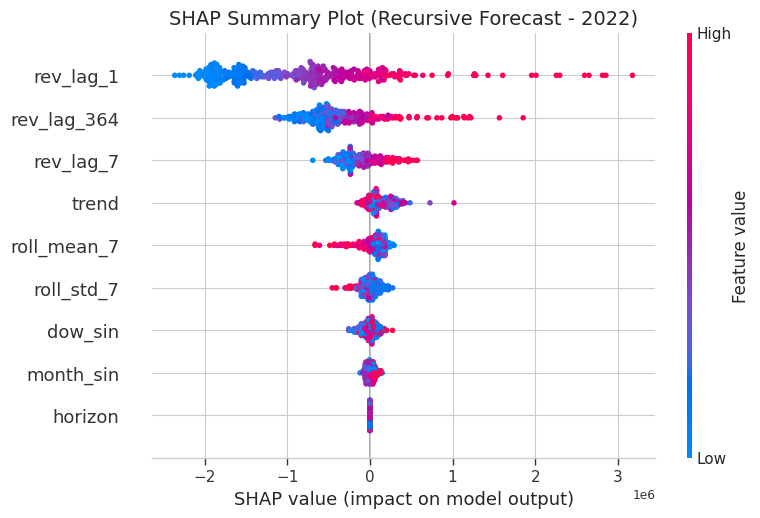

In [68]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap_true, show=False)
plt.title("SHAP Summary Plot (Recursive Forecast - 2022)", fontsize=14)
plt.show()

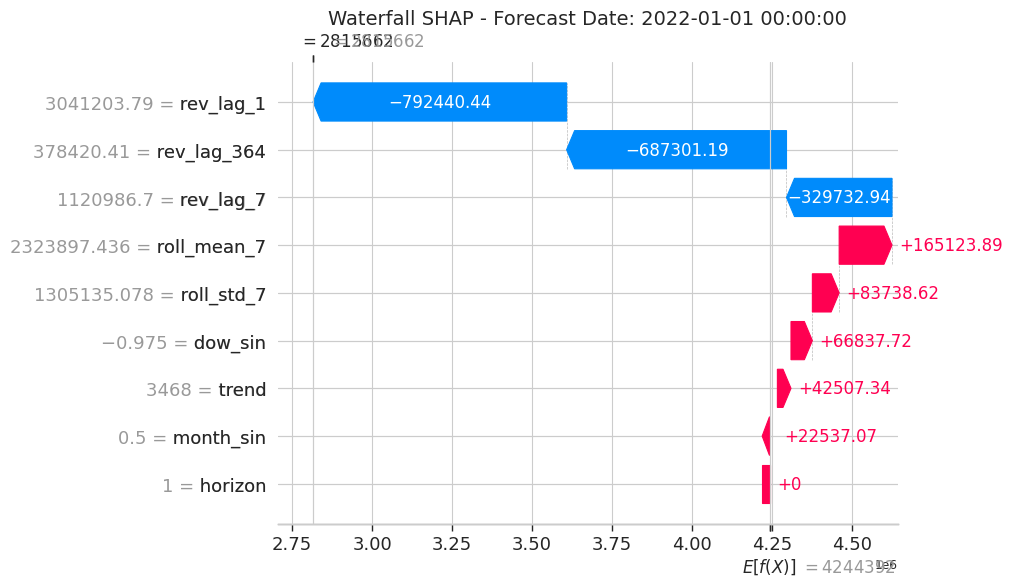

In [69]:
plt.figure(figsize=(10, 6))

idx = 0

shap.plots.waterfall(shap_values[idx], max_display=10, show=False)

plt.title(f"Waterfall SHAP - Forecast Date: {target_dates[idx]}", fontsize=14)
plt.show()